In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from custom_vision_transformer import vit_b_16, ViT_B_16_Weights
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("GPU visible :", torch.cuda.current_device())
print("Nom du GPU :", torch.cuda.get_device_name(torch.cuda.current_device()))

cuda
GPU visible : 0
Nom du GPU : NVIDIA GeForce RTX 2080


/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU2 Quadro P400 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/home/cherr-24/venvs/venv1/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
Quadro P400 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Quadro P400 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [3]:
# --- parameters ---
batch_size = 32
img_size = 224
num_channels = 3
num_classes = 10

In [5]:
# --- load model ---
weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights).to(device)
model.eval();

In [6]:
# from custom_vision_transformer import vit_custom_16

# model = vit_custom_16(num_classes=10, attention_bias=False)
# print(model.heads)

In [7]:
# --- load data ---
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize( # mean and std for ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

imagenet_index_map = { # mapping des labels ImageFolder -> indices ImageNet
    0: 0,    # tench
    1: 217,  # English springer
    2: 482,  # cassette player
    3: 491,  # chain saw
    4: 497,  # church
    5: 566,  # French horn
    6: 569,  # garbage truck
    7: 571,  # gas pump
    8: 574,  # golf ball
    9: 701   # parachute
}

train_dataset = datasets.ImageFolder(root="data/imagenette2-320/train", transform=transform)
val_dataset = datasets.ImageFolder(root="data/imagenette2-320/val", transform=transform)
# # fonction pour convertir les labels
# train_dataset.samples = [(path, imagenet_index_map[label]) for path, label in train_dataset.samples]
# val_dataset.samples = [(path, imagenet_index_map[label]) for path, label in val_dataset.samples]

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

Number of training samples: 9469
Number of validation samples: 3925


In [8]:
# mask for filtering indices that are not in imagenette
imagenette_indices = torch.tensor([0, 217, 482, 491, 497, 566, 569, 571, 574, 701])
mask = torch.zeros(1000, dtype=torch.bool)
mask[imagenette_indices] = True

In [9]:
def get_full_accuracy(model, dataloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, total=len(dataloader)):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            outputs = outputs[:, mask] # filter out indices not in imagenette
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [10]:
val_accuracy = get_full_accuracy(model, val_loader)

print(f"Accuracy: {val_accuracy*100:.2f}%")

100%|██████████| 123/123 [00:34<00:00,  3.54it/s]

Accuracy: 99.92%


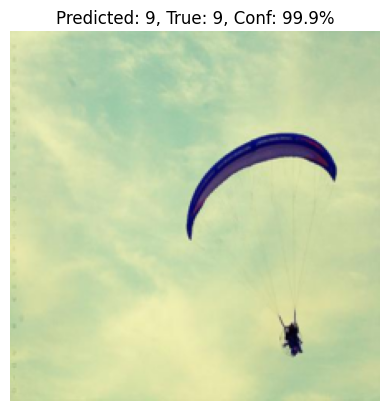

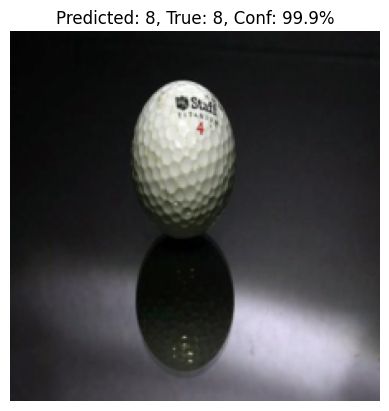

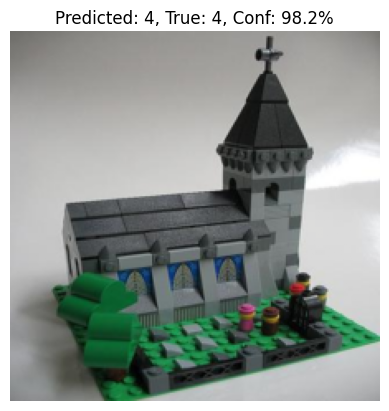

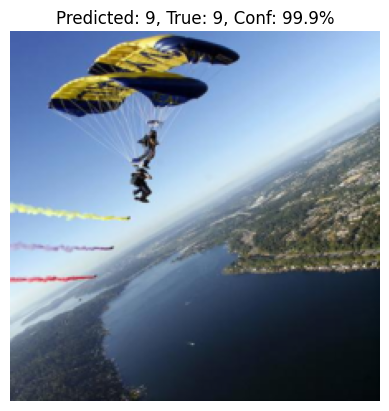

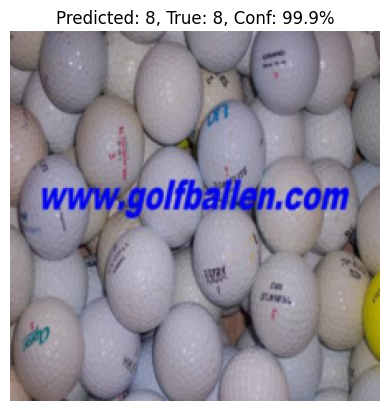

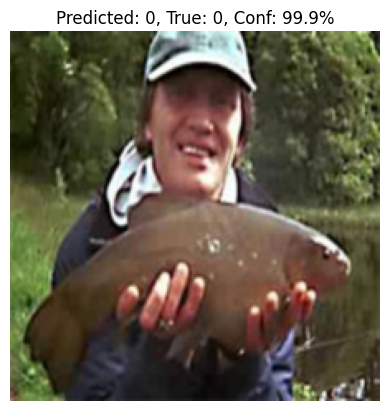

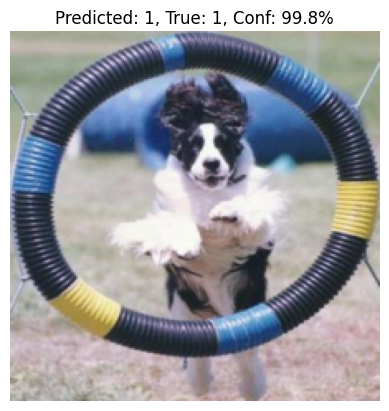

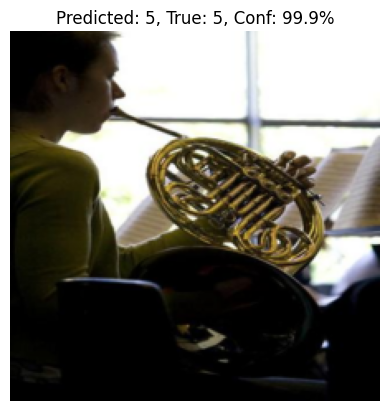

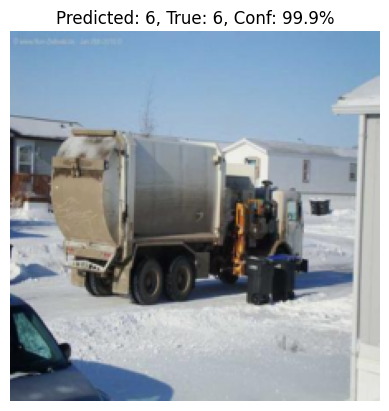

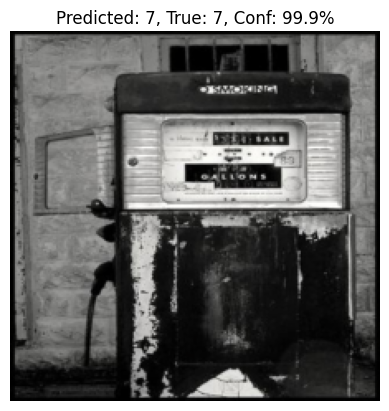

In [ ]:
# --- récupérer une dizaine d’images ---
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# limiter à 10 images
num_display = min(10, images.size(0))
images = images[:num_display]
labels = labels[:num_display]

# --- faire les prédictions ---
with torch.no_grad():
    outputs = model(images)
    outputs = outputs[:, mask] # filter out indices not in imagenette
    probs = F.softmax(outputs, dim=1)
    conf, predicted = torch.max(probs, dim=1)

# --- affichage ---
for i in range(num_display):
    img = images[i].cpu()
    # convertir Tensor en image (denormaliser)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    img = img.permute(1,2,0).numpy()  # CxHxW -> HxWxC
    img = img.clip(0,1)
    
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted[i].item()}, True: {labels[i].item()}, Conf: {conf[i].item()*100:.1f}%")
    plt.show()